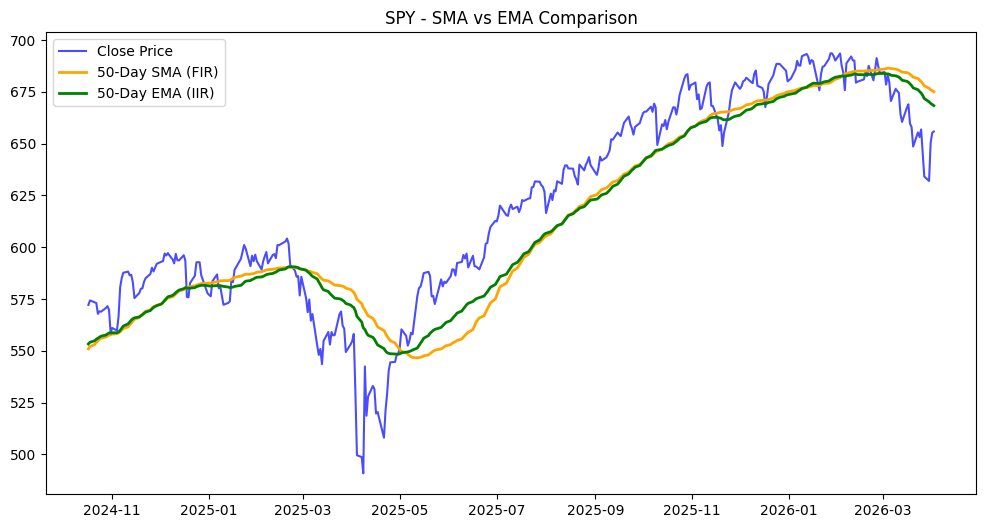

In [10]:

import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import pandas as pd
from scipy import signal, stats
import warnings
TICKER = 'SPY'
INTERVAL = '1d'
WINDOW = 50
df = yf.download(TICKER, start="1993-01-01", interval=INTERVAL, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

df['SMA'] = df['Close'].rolling(WINDOW).mean()
df['EMA'] = df['Close'].ewm(span=WINDOW, adjust=False).mean()
df_subset = df.iloc[-365:]
plt.figure(figsize=(12, 6))

plt.plot(df_subset.index, df_subset['Close'], label='Close Price', color='blue', alpha=0.7)
plt.plot(df_subset.index, df_subset['SMA'], label='50-Day SMA (FIR)', color='orange', lw=2)
plt.plot(df_subset.index, df_subset['EMA'], label='50-Day EMA (IIR)', color='green', lw=2)
plt.title(f"{TICKER} - SMA vs EMA Comparison")
plt.legend()
plt.show()